https://www.geeksforgeeks.org/machine-learning/image-classification-using-support-vector-machine-svm-in-python/

Import required libraries
Load the image and convert it to a dataframe.
 separate input features and targets.
Split train and test value.
Build and train the model
Model evaluation.
Prediction

## Support Vector Machine (SVM) workflow for bee image classification

1. **Import libraries**  
   Load `numpy`, `pandas`, `opencv`/`PIL`, `sklearn` (SVC, train_test_split, metrics), and any plotting tools.

2. **Load metadata**  
   Read `data/bee_data.csv` into a DataFrame. Identify the image filename column and the label column.

3. **Load and preprocess images**  
   - Build full paths to images in `data/bee_imgs/` using the filename column.  
   - Read each image, resize to a fixed size (e.g., 128×128), and convert to RGB or grayscale.  
   - Normalize pixel values to [0, 1].  
   - Flatten each image into a 1D feature vector.

4. **Prepare features and targets**  
   - `X`: stacked flattened image vectors.  
   - `y`: labels from the CSV.  
   - Encode labels if needed (e.g., `LabelEncoder`).

5. **Train/validation split**  
   Split `X` and `y` into training and test sets (e.g., 80/20), with stratification if classes are imbalanced.

6. **Model selection and training**  
   - Initialize `SVC` (start with `kernel="rbf"`).  
   - Optionally tune `C` and `gamma` using grid search or cross-validation.  
   - Fit the model on the training set.
   RBF kernel: strong default

StandardScaler: essential for SVM

class_weight='balanced': handles healthy vs unhealthy imbalance automatically

7. **Evaluation**  
   - Predict on the test set.  
   - Report accuracy, precision, recall, F1-score, and a confusion matrix.

8. **Save results**  
   Store metrics and plots in `results/` (e.g., classification report and confusion matrix image).

((9. **Prediction on new images**  
   Apply the same preprocessing pipeline, then call `model.predict()` on the flattened image vector.))

## 1. Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.svm import SVC

## 2. Load metadata

In [7]:
# Load the CSV file with metadata
bee_data = pd.read_csv("../data/bee_data.csv")

# Identify filename and label columns
filename_col = "file"
label_col = "health"

print(bee_data.head())
print(bee_data.shape)
print("\nLabel distribution:")
print(bee_data[label_col].value_counts())

          file     date   time        location  zip code subspecies  \
0  041_066.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
1  041_072.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
2  041_073.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
3  041_067.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
4  041_059.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   

              health  pollen_carrying   caste  
0  hive being robbed            False  worker  
1  hive being robbed            False  worker  
2  hive being robbed            False  worker  
3  hive being robbed            False  worker  
4  hive being robbed            False  worker  
(5172, 9)

Label distribution:
health
healthy                       3384
few varrao, hive beetles       579
Varroa, Small Hive Beetles     472
ant problems                   457
hive being robbed              251
missing queen                   29
Name: count, dtype: int64


## 3. Load and preprocess images

In [8]:
# Load images from bee_imgs, resize, normalize, and flatten
target_size = (128, 128)

def load_and_preprocess_image(filename, target_size=target_size):
    img_path = os.path.join("../data/bee_imgs", filename)
    img = Image.open(img_path).convert("RGB").resize(target_size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr.flatten()

image_arrays = []
for filename in bee_data[filename_col]:
    image_arrays.append(load_and_preprocess_image(filename))

X = np.vstack(image_arrays)
y = bee_data[label_col].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5172, 49152)
y shape: (5172,)


## 4. Prepare features and targets

In [9]:
# X already created above from flattened images
print(f"X dtype: {X.dtype}")

# Create binary labels: healthy vs unhealthy
y_binary = np.where(bee_data[label_col].values == "healthy", "healthy", "unhealthy")
print("Binary class distribution:")
print(pd.Series(y_binary).value_counts())

# Encode labels for modeling
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_binary)

print("Classes:", list(label_encoder.classes_))
print(f"y_encoded shape: {y_encoded.shape}")

X dtype: float32
Binary class distribution:
healthy      3384
unhealthy    1788
Name: count, dtype: int64
Classes: [np.str_('healthy'), np.str_('unhealthy')]
y_encoded shape: (5172,)


## 5. Train/validation split

In [10]:
# Split data into train and test sets (stratified)
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
 )

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

x_train shape: (4137, 49152)
y_train shape: (4137,)
x_test shape: (1035, 49152)
y_test shape: (1035,)

Train class distribution:
0    2707
1    1430
Name: count, dtype: int64

Test class distribution:
0    677
1    358
Name: count, dtype: int64


## 6. Model selection and training

PCA components: 183
Explained variance (sum): 0.9501191


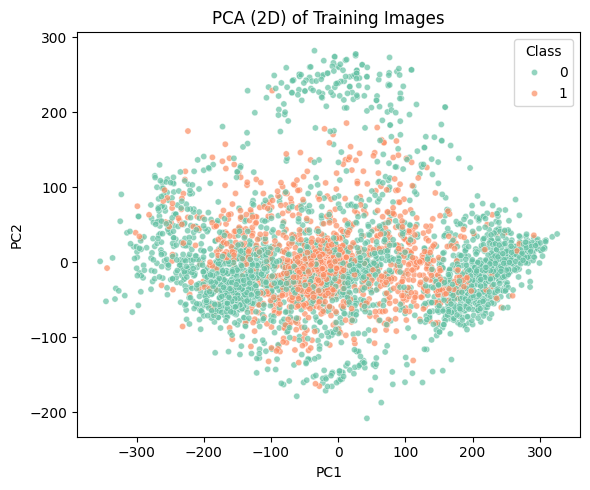

In [11]:
# 6a. PCA for dimensionality reduction + visualization
from sklearn.decomposition import PCA

# Scale before PCA (use existing x_train_scaled/x_test_scaled from next cell if needed)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Keep 95% variance (adjust as needed)
pca = PCA(n_components=0.95, random_state=42)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("PCA components:", pca.n_components_)
print("Explained variance (sum):", pca.explained_variance_ratio_.sum())

# 2D visualization (first two PCs)
pca_2d = PCA(n_components=2, random_state=42)
x_train_2d = pca_2d.fit_transform(x_train_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=x_train_2d[:, 0],
    y=x_train_2d[:, 1],
    hue=y_train,
    palette="Set2",
    s=20,
    alpha=0.7
 )
plt.title("PCA (2D) of Training Images")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [12]:
# Baseline SVM model (simple)

# SVMs are sensitive to feature scales, so we standardize first
# (Scaling already done in PCA cell)

# Manual hyperparameters (start with defaults, tune later if needed)
C_value = 1.0       # Regularization strength (higher = less regularization)
gamma_value = "scale"  # Kernel coefficient for RBF ("scale" is a safe default)

# Baseline model: RBF kernel is a strong default for non-linear boundaries
svm_model = SVC(kernel="rbf", C=C_value, gamma=gamma_value)
svm_model.fit(x_train_pca, y_train)

print("Baseline SVM trained.")

# Simple grid search (optional, bachelor-level)
use_grid_search = False  # set to False to skip and keep the baseline
if use_grid_search:
    
    param_grid = {
        "C": [0.1, 1, 10],
        "gamma": [1e-3, 1e-4],
        "kernel": ["rbf"]
    }
    grid = GridSearchCV(
        SVC(),
        param_grid=param_grid,
        cv=3,               # 3-fold cross-validation
        scoring="f1",        # suitable for binary classification
        n_jobs=-1,
        verbose=1
    )
    grid.fit(x_train_pca, y_train)
    svm_model = grid.best_estimator_
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)

Baseline SVM trained.


## 7. Evaluation

Accuracy: 0.9469

Classification Report:
              precision    recall  f1-score   support

     healthy       0.94      0.98      0.96       677
   unhealthy       0.96      0.88      0.92       358

    accuracy                           0.95      1035
   macro avg       0.95      0.93      0.94      1035
weighted avg       0.95      0.95      0.95      1035



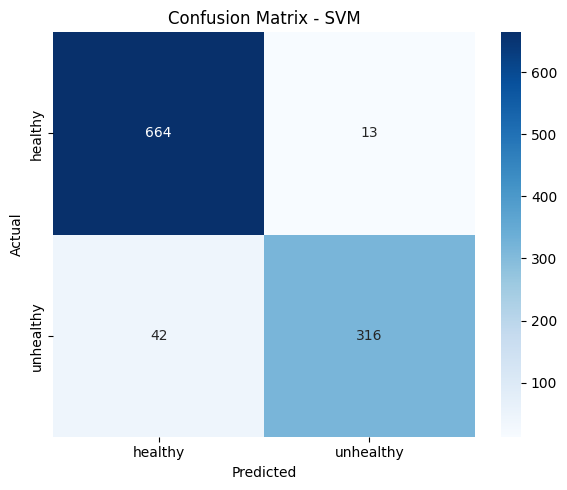

In [13]:
# Predict on the test set
y_pred = svm_model.predict(x_test_pca)

# Metrics
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
 )
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()